# **K-Nearest Neighbors with Optuna**

**Part B — the same KNN workflow, with two ways to use Optuna.**

We keep the Iris dataset and the model from the KNN notebook. First, we fit and inspect a KNN model. Then we tune `n_neighbors` and `weights` with Optuna, one idea at a time:

1. **Native Optuna with a single validation split**: the core loop (`objective()` → `study.optimize()`).
2. **Cross-validation**: the same loop with a better evaluation, written in two ways (`OptunaSearchCV` and native Optuna).
3. **Grid Search, Random Search, and TPE**: the same CV setup; only the sampler changes.

# **1. Load Iris Plants Dataset**

Dataset and description retained from the KNN notebook. See also the [scikit-learn Iris loader documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html).

In [ ]:
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
from sklearn.datasets import load_iris
iris = load_iris()
iris_df =  pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['target_names'] = [iris.target_names[t] for t in iris.target]
target_col = 'target'
feature_col = iris.feature_names

In [ ]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


<u>**Data Set Characteristics**</u>

**Number of Instances**: 150 (50 in each of three classes)  
**Number of Attributes**: 4 numeric, predictive attributes and the class  

<u>**Attribute Information**</u>
- sepal length in cm  
- sepal width in cm  
- petal length in cm  
- petal width in cm  
- class:  
  - Iris-Setosa  
  - Iris-Versicolour  
  - Iris-Virginica  

<u>**Summary Statistics**</u>

| Features | Min | Max | Mean | SD | Class Correlation |
|-:|-:|-:|-:|-:|-:|
| sepal length | 4.3 | 7.9 | 5.84 | 0.83 | 0.7826 |
| sepal width | 2.0 | 4.4 | 3.05 | 0.43 | -0.4194 |
| petal length | 1.0 | 6.9 | 3.76 | 1.76 | 0.9490 (high!) |
| petal width | 0.1 | 2.5 | 1.20 | 0.76 | 0.9565 (high!) |

**Missing Attribute Values**: None  
**Class Distribution**: 33.3% for each of 3 classes.  
**Creator**: R.A. Fisher  
**Donor**: Michael Marshall (MARSHALL%PLU@io.arc.nasa.gov)  
**Date**: July, 1988  

The famous Iris database, first used by Sir R.A. Fisher. The dataset is taken
from Fisher's paper. Note that it's the same as in R, but not as in the UCI
Machine Learning Repository, which has two wrong data points.  

This is perhaps the best known database to be found in the
pattern recognition literature.  Fisher's paper is a classic in the field and
is referenced frequently to this day.  (See Duda & Hart, for example.)  The
data set contains 3 classes of 50 instances each, where each class refers to a
type of iris plant.  One class is linearly separable from the other 2; the
latter are NOT linearly separable from each other.  

**References**
- Fisher, R.A. "The use of multiple measurements in taxonomic problems"
  Annual Eugenics, 7, Part II, 179-188 (1936); also in "Contributions to
  Mathematical Statistics" (John Wiley, NY, 1950).
- Duda, R.O., & Hart, P.E. (1973) Pattern Classification and Scene Analysis.
  (Q327.D83) John Wiley & Sons.  ISBN 0-471-22361-1.  See page 218.
- Dasarathy, B.V. (1980) "Nosing Around the Neighborhood: A New System
  Structure and Classification Rule for Recognition in Partially Exposed
  Environments".  IEEE Transactions on Pattern Analysis and Machine
  Intelligence, Vol. PAMI-2, No. 1, 67-71.
- Gates, G.W. (1972) "The Reduced Nearest Neighbor Rule".  IEEE Transactions
  on Information Theory, May 1972, 431-433.
- See also: 1988 MLC Proceedings, 54-64.  Cheeseman et al"s AUTOCLASS II
  conceptual clustering system finds 3 classes in the data.
- Many, many more ...

In [ ]:
from sklearn.model_selection import train_test_split

X = iris_df[feature_col]
y = iris_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.30, random_state=30)

# **2. K-Nearest Neighbors**

For Classification: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html  
For Regression: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

**Starting parameters:** `n_neighbors=5` and `weights="distance"`.

We first choose these values ourselves. In Section 4, we let Optuna search for them.

In [ ]:
n_neighbors = 5 #@param {type:"slider", min:1, max:10, step:1}
weights = 'distance'  #@param ['uniform', 'distance']

knn = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    weights=weights,
)

knn.fit(X_train, y_train)

KNeighborsClassifier(weights='distance')

In [ ]:
# Predict as Class
train_predict = knn.predict(X_train)
test_predict = knn.predict(X_test)

# Predict as Probability
train_predict_prob = knn.predict_proba(X_train)

In [ ]:
# Show the first 10 predicted classes.
print(train_predict[:10])

# Each row contains probabilities for classes 0, 1, and 2.
print("Probability column order:", knn.classes_)
print(train_predict_prob[:10])

[0 1 1 2 2 1 2 2 2 1]
Probability column order: [0 1 2]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [ ]:
# Actual Target
y_train[:10].tolist()

[0, 1, 1, 2, 2, 1, 2, 2, 2, 1]

In [ ]:
from sklearn.metrics import confusion_matrix

# Include all three Iris classes.
confusion_matrix(y_test, test_predict, labels=knn.classes_)

array([[15,  0,  0],
       [ 0, 13,  2],
       [ 0,  1, 14]])

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_predict, digits=4))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        15
           1     0.9286    0.8667    0.8966        15
           2     0.8750    0.9333    0.9032        15

    accuracy                         0.9333        45
   macro avg     0.9345    0.9333    0.9333        45
weighted avg     0.9345    0.9333    0.9333        45



# **3. Visualization**

Adapt from: https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html

**Illustration only:** this is the source notebook's separate, two-feature model,
fitted on all Iris rows so that we can draw its decision boundary. It is not the
four-feature model evaluated above or tuned below. Do not use this plot, or the
test predictions, to choose the search settings in Section 4.

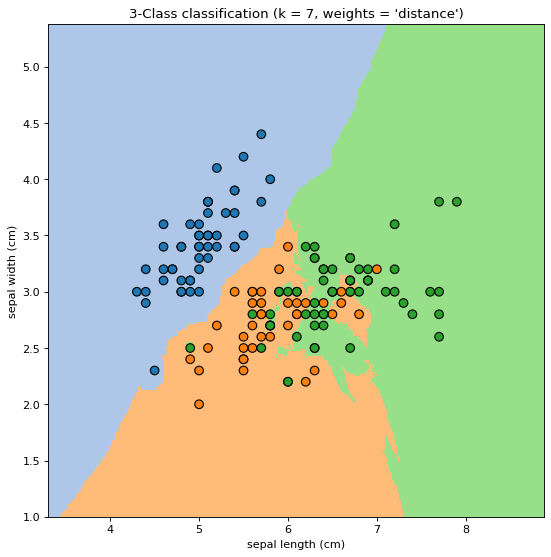

In [ ]:
#@markdown # **Select parameters to plot**
#@markdown **(Simplified illustration - 2 features)**
n_neighbors = 7 #@param {type:"slider", min:1, max:10, step:1}
weights = 'distance'  #@param ['uniform', 'distance']
x_label = 'sepal length (cm)' #@param ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
y_label = 'sepal width (cm)' #@param ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

if x_label == y_label:
    raise ValueError("Choose two different features for the visualization.")

x_idx = iris_df.columns.to_list().index(x_label)
y_idx = iris_df.columns.to_list().index(y_label)

from matplotlib.colors import ListedColormap
cmap_val = np.linspace(0.0, 1.0, 20)
tab20 = plt.colormaps['tab20']
cmap_light = ListedColormap(tab20(cmap_val)[1:7:2])
cmap_bold = ListedColormap(tab20(cmap_val)[:6:2])
h = .02  # step size in the mesh

visual_model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)
visual_model.fit(iris_df.iloc[:, [x_idx, y_idx]], iris_df[target_col])
x_min, x_max = iris_df.iloc[:, x_idx].min() - 1, iris_df.iloc[:, x_idx].max() + 1
y_min, y_max = iris_df.iloc[:, y_idx].min() - 1, iris_df.iloc[:, y_idx].max() + 1
xx, yy = np.meshgrid(
  np.arange(x_min, x_max, h),
  np.arange(y_min, y_max, h)
)

mesh_points = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=[x_label, y_label]
)
Z = visual_model.predict(mesh_points)

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 8), dpi=80)
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(
  iris_df.iloc[:, x_idx],
  iris_df.iloc[:, y_idx],
  c=iris_df[target_col],
  cmap=cmap_bold,
  edgecolor='k',
  s=60
)
plt.xlabel(x_label)
plt.xlim(xx.min(), xx.max())
plt.ylabel(y_label)
plt.ylim(yy.min(), yy.max())
plt.title("3-Class classification (k = %i, weights = '%s')"
          % (n_neighbors, weights))
plt.show()

# **4. Find the best K value**

**Setup.** `OptunaSearchCV` belongs to the separate `optuna-integration` package, not the core optimization API. Install its scikit-learn extra as well as Optuna.

The native examples do not require the integration package, but the `OptunaSearchCV` examples do.

In [ ]:
%pip install -q "optuna==4.8.0" "optuna-integration[sklearn]==4.8.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.1 MB/s eta 0:00:00


In [ ]:
import optuna
import sklearn
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 30

print("Optuna:", optuna.__version__)
print("scikit-learn:", sklearn.__version__)

Optuna: 4.8.0
scikit-learn: 1.6.1


## 4.1. Native Optuna with a Single Validation Split

We start with the simplest native Optuna workflow and leave cross-validation for later. The whole idea fits in one sentence:

> **Optuna asks for parameters → we evaluate them → the objective returns one number → Optuna optimizes that number.**

Three Optuna objects do this work:

| Object | What it is |
|-|-|
| **`Study`** | One optimization run. It stores every trial and knows whether to `maximize` or `minimize`. |
| **`Trial`** | One attempt: one set of hyperparameters and the score it received. |
| **`trial.suggest_*()`** | How a trial asks Optuna for a value, e.g. `suggest_int()` or `suggest_categorical()`. The first argument is the parameter name. |

To evaluate a parameter pair, we need data that the model was not trained on. We split the training data again into:

- **sub-training set** — used to fit the model
- **validation set** — used to score each hyperparameter configuration

The original test set is kept untouched until the final evaluation.

In [ ]:
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42,
)

print("Sub-training set:", X_subtrain.shape)
print("Validation set  :", X_valid.shape)
print("Test set        :", X_test.shape)

Sub-training set: (84, 4)
Validation set  : (21, 4)
Test set        : (45, 4)


**Write the objective.** Optuna calls `objective(trial)` once per trial. Inside it, we ask for parameters with `trial.suggest_*()`, fit the model, and **return one number**. The search space is written directly in these calls: `n_neighbors` from 1 to 10, and `weights` from two choices.

In [ ]:
from sklearn.metrics import f1_score

def objective_single_split(trial):
    # 1. Ask Optuna for one hyperparameter configuration.
    n_neighbors = trial.suggest_int("n_neighbors", 1, 10)
    weights = trial.suggest_categorical(
        "weights",
        ["uniform", "distance"]
    )

    # 2. Create the model.
    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
    )

    # 3. Train on the training split.
    knn.fit(X_subtrain, y_subtrain)

    # 4. Evaluate on the validation split.
    y_pred = knn.predict(X_valid)

    # 5. Return one score for Optuna to maximize.
    return f1_score(
        y_valid,
        y_pred,
        average="weighted",
    )

**Create a study and optimize.** `direction="maximize"` because a higher F1 is better. `n_trials=20` is the search budget: Optuna calls `objective_single_split()` twenty times.

The **sampler** decides which parameters each trial gets. We use `TPESampler`, Optuna's default, with a seed so that the results repeat. Sections 4.3–4.5 compare samplers; for now, only the loop matters.

In [ ]:
study_single = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),  # Optuna's default sampler, seeded.
)

study_single.optimize(
    objective_single_split,
    n_trials=20,
)

print("Best params:", study_single.best_params)
print(f"Best validation weighted F1: {study_single.best_value:.4f}")

Best params: {'n_neighbors': 7, 'weights': 'distance'}
Best validation weighted F1: 1.0000


**Look inside the study.** Each row is one `Trial`. `value` is the number our objective returned — here, the weighted F1 on the single validation set.

Notice that **every trial scores 1.0**. In fact, all 20 parameter pairs classify these 21 validation rows perfectly. Optuna cannot prefer one pair over another, so `best_params` is simply the first trial that reached the best value.

In [ ]:
study_single.trials_dataframe()[
    ["number", "value", "params_n_neighbors", "params_weights", "state"]
]

,number,value,params_n_neighbors,params_weights,state
0,0,1.0,7,distance,COMPLETE
1,1,1.0,2,uniform,COMPLETE
2,2,1.0,10,distance,COMPLETE
3,3,1.0,5,distance,COMPLETE
4,4,1.0,6,distance,COMPLETE
5,5,1.0,1,distance,COMPLETE
6,6,1.0,3,distance,COMPLETE
7,7,1.0,8,uniform,COMPLETE
8,8,1.0,10,distance,COMPLETE
9,9,1.0,4,distance,COMPLETE


## 4.2. Cross-Validation with Optuna

A single validation split is simple, but its score depends on which rows happen to land in the validation set. In 4.1, the 21 validation rows were easy enough that **every parameter pair scored 1.0**, so the search had nothing to optimize. With a different split, a single misclassified flower could change the F1 noticeably.

We can make the evaluation more reliable by switching to **5-fold cross-validation**: each parameter pair is scored on five different validation folds of `X_train`, and the mean score is used. The optimization idea stays the same; only the **evaluation procedure** changes.

There are two ways to do this:

- **4.2.1. `OptunaSearchCV`** — a scikit-learn-style wrapper that runs the CV for us.
- **4.2.2. Native Optuna** — we put `cross_val_score()` inside our own objective.

For this classifier, `cv=5` uses stratified folds without shuffling. Both interfaces therefore use the same folds on the same training rows. Neither the sampler seed nor the trial number changes these folds. [2, 3] We keep the original four features and add no scaling step. Each example runs sequentially with `n_jobs=1`.

### 4.2.1. OptunaSearchCV

`OptunaSearchCV` is the scikit-learn integration: it provides a familiar `.fit()` interface and runs cross-validation for each candidate. It uses an Optuna `Study` internally, so we do not write `objective()` or call `study.optimize()` ourselves. [1, 2]

In exchange, we describe the search space as **distributions** instead of `trial.suggest_*()` calls. `param_distributions` below is the same search space as in `objective_single_split()`: the names and ranges must agree.

In [ ]:
from optuna_integration import OptunaSearchCV

In [ ]:
from optuna.distributions import IntDistribution, CategoricalDistribution

param_distributions = {
    "n_neighbors": IntDistribution(1, 10),                              # trial.suggest_int("n_neighbors", 1, 10)
    "weights": CategoricalDistribution(["uniform", "distance"]),         # trial.suggest_categorical("weights", [...])
}

In the code below, **`cv=5` is all we need for cross-validation** — the wrapper splits the folds, fits five models per trial, and averages their scores. `n_trials=20` sets the search budget, so **one trial evaluates one parameter pair over five folds**. `refit=True` then trains a separate final model with the best parameters on all training rows. [2]

We pass a fresh study with the same seeded `TPESampler` as in 4.1, so that the only new idea is CV.

The integration may display an `ExperimentalWarning` in this version. This warns about API stability; it is not a failed model fit. [2]

In [ ]:
cv_search_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

cv_search = OptunaSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_distributions,
    scoring="f1_weighted",
    cv=5,                      # Five CV folds for each parameter pair.
    n_trials=20,               # Up to twenty parameter pairs.
    study=cv_search_study,
    refit=True,                # Fit the selected model on all X_train.
    n_jobs=1,
    error_score="raise",
)

cv_search.fit(X_train, y_train)

/tmp/ipykernel_4247/1630441692.py:6: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  cv_search = OptunaSearchCV(


OptunaSearchCV(cv=5, error_score='raise', estimator=KNeighborsClassifier(),
               n_jobs=1, n_trials=20,
               param_distributions={'n_neighbors': IntDistribution(high=10, log=False, low=1, step=1),
                                    'weights': CategoricalDistribution(choices=('uniform', 'distance'))},
               scoring='f1_weighted',
               study=<optuna.study.study.Study object at 0x7e57a4501bd0>)

In [ ]:
print("Best parameters:", cv_search.best_params_)
print(f"Best CV weighted F1: {cv_search.best_score_:.4f}")

# The wrapper exposes its Optuna study after fitting.
cv_search.study_.trials_dataframe()[
    ["number", "value", "params_n_neighbors", "params_weights", "state"]
]

Best parameters: {'n_neighbors': 7, 'weights': 'distance'}
Best CV weighted F1: 0.9809


,number,value,params_n_neighbors,params_weights,state
0,0,0.980855,7,distance,COMPLETE
1,1,0.951935,2,uniform,COMPLETE
2,2,0.980855,10,distance,COMPLETE
3,3,0.971282,5,distance,COMPLETE
4,4,0.971282,6,distance,COMPLETE
5,5,0.961807,1,distance,COMPLETE
6,6,0.980855,3,distance,COMPLETE
7,7,0.971380,8,uniform,COMPLETE
8,8,0.980855,10,distance,COMPLETE
9,9,0.961807,4,distance,COMPLETE


**Use the fitted model.** With `refit=True`, `best_estimator_` is already trained. No additional `.fit()` is needed. These are example predictions, not another CV score. [2]

In [ ]:
cv_search_model = cv_search.best_estimator_
cv_search_model.predict(X_test)[:10]

array([2, 0, 2, 1, 2, 0, 1, 0, 2, 2])

### 4.2.2. Native Optuna with Cross-Validation

With native Optuna, we change only the **evaluation part** of the objective. Compare it with `objective_single_split()`:

| | `objective_single_split()` | `objective_cv()` |
|-|-|-|
| Ask for parameters | `trial.suggest_*()` | `trial.suggest_*()` — unchanged |
| Create the model | `KNeighborsClassifier(...)` | unchanged |
| Evaluate | fit on `X_subtrain`, score on `X_valid` | `cross_val_score(..., cv=5)` on `X_train` |
| Return | one F1 score | the **mean** of five F1 scores |

Steps 1 and 2 are identical. Only steps 3–5 are replaced.

In [ ]:
def objective_cv(trial):
    # 1. Ask Optuna for one hyperparameter configuration.  (unchanged)
    n_neighbors = trial.suggest_int("n_neighbors", 1, 10)
    weights = trial.suggest_categorical(
        "weights",
        ["uniform", "distance"]
    )

    # 2. Create the model.  (unchanged)
    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
    )

    # 3-4. Evaluate with 5-fold CV on all training rows.  (changed)
    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        scoring="f1_weighted",
        cv=5,
    )

    # 5. Return one score for Optuna to maximize: the mean over five folds.
    return scores.mean()

**The optimization workflow does not change. Only the evaluation inside the objective changes.**

```python
study.optimize(objective_single_split, n_trials=20)
```

becomes

```python
study.optimize(objective_cv, n_trials=20)
```

We create a **new study** rather than continuing `study_single`, because its trial values were measured in a different way. We use the same seeded `TPESampler` as before.

In [ ]:
study_cv = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

study_cv.optimize(
    objective_cv,
    n_trials=20,
)

print("Best parameters:", study_cv.best_params)
print(f"Best CV weighted F1: {study_cv.best_value:.4f}")

Best parameters: {'n_neighbors': 7, 'weights': 'distance'}
Best CV weighted F1: 0.9809


**Get the search results.** In `trials_dataframe()`, `value` is the mean CV weighted F1 returned by the objective. It is not a test score. Trial numbering starts at 0. [6]

In [ ]:
cv_result = study_cv.trials_dataframe()
cv_result[
    ["number", "value", "params_n_neighbors", "params_weights", "state"]
]

,number,value,params_n_neighbors,params_weights,state
0,0,0.980855,7,distance,COMPLETE
1,1,0.951935,2,uniform,COMPLETE
2,2,0.980855,10,distance,COMPLETE
3,3,0.971282,5,distance,COMPLETE
4,4,0.971282,6,distance,COMPLETE
5,5,0.961807,1,distance,COMPLETE
6,6,0.980855,3,distance,COMPLETE
7,7,0.971380,8,uniform,COMPLETE
8,8,0.980855,10,distance,COMPLETE
9,9,0.961807,4,distance,COMPLETE


**Train the selected model.** A native study stores the search results, not a fitted `best_estimator_`. Create a new KNN from `best_params`, then fit it on all training rows. [6]

Several parameter pairs may share the best score. A different search order can therefore select a different tied pair.

In [ ]:
cv_model = KNeighborsClassifier(**study_cv.best_params)
cv_model.fit(X_train, y_train)

cv_model.predict(X_test)[:10]

array([2, 0, 2, 1, 2, 0, 1, 0, 2, 2])

**Two ways, one idea.** Both versions score each parameter pair with the same 5-fold CV.

| | `OptunaSearchCV` | Native Optuna |
|-|-|-|
| Search space | `param_distributions` | `trial.suggest_*()` inside `objective()` |
| Cross-validation | `cv=5` — done by the wrapper | `cross_val_score(..., cv=5)` — written by us |
| Run the search | `.fit(X_train, y_train)` | `study.optimize(objective_cv, n_trials=...)` |
| Final model | `best_estimator_` (with `refit=True`) | fit `KNeighborsClassifier(**study.best_params)` ourselves |

From here on, we keep **both** evaluation setups fixed and change only one thing: the **sampler**.

## 4.3. Grid Search with Optuna

Now that the evaluation is settled, Grid Search, Random Search, and TPE differ only in the line that creates the sampler:

```python
optuna.samplers.GridSampler(...)
optuna.samplers.RandomSampler(...)
optuna.samplers.TPESampler(...)
```

`GridSampler` needs the exact values it must visit. `grid_space` lists them; they must stay inside the search space used by `param_distributions` and `objective_cv()`. [2, 4]

There are **10 × 2 = 20 combinations**. We allow 20 trials so that the grid can be completed. In this sequential example, `GridSampler` visits each combination and stops once the grid is exhausted. Its seed controls the order, not the set of combinations. [4]

In [ ]:
grid_space = {
    "n_neighbors": list(range(1, 11)),
    "weights": ["uniform", "distance"],
}

print("Grid size:", len(grid_space["n_neighbors"]) * len(grid_space["weights"]))

Grid size: 20


### 4.3.1. OptunaSearchCV + GridSampler

The `OptunaSearchCV` code is the same as in 4.2.1. We pass a fresh study whose sampler is `GridSampler`. **`GridSampler` makes it Grid Search**: the wrapper is responsible for fitting and CV; it is not itself the search strategy.

In [ ]:
# A fresh study for the SearchCV version.
grid_cv_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.GridSampler(grid_space, seed=SEED),
)

grid_search = OptunaSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_distributions,
    scoring="f1_weighted",
    cv=5,                      # Five CV folds for each parameter pair.
    n_trials=20,               # Up to twenty parameter pairs.
    study=grid_cv_study,
    refit=True,               # Fit the selected model on all X_train.
    n_jobs=1,
    error_score="raise",
)

grid_search.fit(X_train, y_train)

/tmp/ipykernel_4247/3927504973.py:7: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  grid_search = OptunaSearchCV(


OptunaSearchCV(cv=5, error_score='raise', estimator=KNeighborsClassifier(),
               n_jobs=1, n_trials=20,
               param_distributions={'n_neighbors': IntDistribution(high=10, log=False, low=1, step=1),
                                    'weights': CategoricalDistribution(choices=('uniform', 'distance'))},
               scoring='f1_weighted',
               study=<optuna.study.study.Study object at 0x7e57a201b6f0>)

In [ ]:
print("Best parameters:", grid_search.best_params_)
print(f"Best CV weighted F1: {grid_search.best_score_:.4f}")

# The wrapper exposes its Optuna study after fitting.
grid_search.study_.trials_dataframe()[
    ["number", "value", "params_n_neighbors", "params_weights", "state"]
]

Best parameters: {'n_neighbors': 8, 'weights': 'distance'}
Best CV weighted F1: 0.9809


,number,value,params_n_neighbors,params_weights,state
0,0,0.971282,6,distance,COMPLETE
1,1,0.961807,1,uniform,COMPLETE
2,2,0.980855,8,distance,COMPLETE
3,3,0.971380,8,uniform,COMPLETE
4,4,0.971282,5,distance,COMPLETE
5,5,0.961807,4,uniform,COMPLETE
6,6,0.961508,6,uniform,COMPLETE
7,7,0.961709,5,uniform,COMPLETE
8,8,0.980855,9,uniform,COMPLETE
9,9,0.961807,2,distance,COMPLETE


In [ ]:
grid_cv_model = grid_search.best_estimator_
grid_cv_model.predict(X_test)[:10]

array([2, 0, 2, 1, 2, 0, 1, 0, 2, 2])

### 4.3.2. Native Optuna + GridSampler

We reuse `objective_cv()` from 4.2.2 unchanged. Only the sampler changes.

In [ ]:
grid_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.GridSampler(grid_space, seed=SEED),
)

grid_study.optimize(objective_cv, n_trials=20, n_jobs=1)

print("Best parameters:", grid_study.best_params)
print(f"Best CV weighted F1: {grid_study.best_value:.4f}")

Best parameters: {'n_neighbors': 8, 'weights': 'distance'}
Best CV weighted F1: 0.9809


In [ ]:
grid_search_result = grid_study.trials_dataframe()
grid_search_result[
    ["number", "value", "params_n_neighbors", "params_weights", "state"]
]

,number,value,params_n_neighbors,params_weights,state
0,0,0.971282,6,distance,COMPLETE
1,1,0.961807,1,uniform,COMPLETE
2,2,0.980855,8,distance,COMPLETE
3,3,0.971380,8,uniform,COMPLETE
4,4,0.971282,5,distance,COMPLETE
5,5,0.961807,4,uniform,COMPLETE
6,6,0.961508,6,uniform,COMPLETE
7,7,0.961709,5,uniform,COMPLETE
8,8,0.980855,9,uniform,COMPLETE
9,9,0.961807,2,distance,COMPLETE


Several parameter pairs may share the best score. A different search order can therefore select a different tied pair.

In [ ]:
grid_model = KNeighborsClassifier(**grid_study.best_params)
grid_model.fit(X_train, y_train)

grid_model.predict(X_test)[:10]

array([2, 0, 2, 1, 2, 0, 1, 0, 2, 2])

## 4.4. Random Search with Optuna

Keep the same model, search space, score, and CV setup. Replace `GridSampler` with **`RandomSampler`**, and keep the source notebook's budget of **10 trials**. [5]

Random sampling can repeat a parameter pair. Ten trials therefore do not necessarily mean ten different pairs, and even twenty random trials would not guarantee a complete grid sweep.

### 4.4.1. OptunaSearchCV + RandomSampler

The `.fit()` workflow stays the same. We pass a fresh study with a `RandomSampler`; the wrapper still performs CV and refits the selected KNN.

In [ ]:
random_cv_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.RandomSampler(seed=SEED),
)

random_search = OptunaSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_distributions,
    scoring="f1_weighted",
    cv=5,
    n_trials=10,
    study=random_cv_study,
    refit=True,
    n_jobs=1,
    error_score="raise",
)

random_search.fit(X_train, y_train)

/tmp/ipykernel_4247/2416140609.py:6: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  random_search = OptunaSearchCV(


OptunaSearchCV(cv=5, error_score='raise', estimator=KNeighborsClassifier(),
               n_jobs=1,
               param_distributions={'n_neighbors': IntDistribution(high=10, log=False, low=1, step=1),
                                    'weights': CategoricalDistribution(choices=('uniform', 'distance'))},
               scoring='f1_weighted',
               study=<optuna.study.study.Study object at 0x7e57a2238ef0>)

In [ ]:
print("Best parameters:", random_search.best_params_)
print(f"Best CV weighted F1: {random_search.best_score_:.4f}")

random_cv_model = random_search.best_estimator_
random_cv_model.predict(X_test)[:10]

Best parameters: {'n_neighbors': 7, 'weights': 'distance'}
Best CV weighted F1: 0.9809


array([2, 0, 2, 1, 2, 0, 1, 0, 2, 2])

### 4.4.2. Native Optuna + RandomSampler

We reuse `objective_cv()` from 4.2.2, so each trial is still evaluated with 5-fold cross-validation. The only change is the sampler: `RandomSampler` selects hyperparameter configurations randomly.

In [ ]:
random_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.RandomSampler(seed=SEED),
)

random_study.optimize(
    objective_cv,
    n_trials=10,
    n_jobs=1,
)

print("Best parameters:", random_study.best_params)
print(f"Best CV weighted F1: {random_study.best_value:.4f}")

Best parameters: {'n_neighbors': 7, 'weights': 'distance'}
Best CV weighted F1: 0.9809


In [ ]:
random_search_result = random_study.trials_dataframe()

random_search_result[
    ["number", "value", "params_n_neighbors", "params_weights", "state"]
]

,number,value,params_n_neighbors,params_weights,state
0,0,0.980855,7,distance,COMPLETE
1,1,0.951935,2,uniform,COMPLETE
2,2,0.980855,10,distance,COMPLETE
3,3,0.971282,5,distance,COMPLETE
4,4,0.971282,6,distance,COMPLETE
5,5,0.961807,1,distance,COMPLETE
6,6,0.980855,3,distance,COMPLETE
7,7,0.971380,8,uniform,COMPLETE
8,8,0.980855,10,distance,COMPLETE
9,9,0.961807,4,distance,COMPLETE


In [ ]:
random_model = KNeighborsClassifier(**random_study.best_params)
random_model.fit(X_train, y_train)

random_model.predict(X_test)[:10]

array([2, 0, 2, 1, 2, 0, 1, 0, 2, 2])

## 4.5. TPE Search with Optuna

TPE (Tree-structured Parzen Estimator) uses previous trial results to guide later suggestions. We already used it as Optuna's default sampler in 4.1 and 4.2; here we look at what it does.

In this example, the first **10 trials** use random sampling; the remaining trials can use that history. We make `n_startup_trials=10` explicit (it is also the default) and run **20 trials** in total. [7] With the same seed and objective, the native run therefore repeats the trials of 4.2.2 — this time we read its history.

TPE can revisit a parameter pair. It does not promise that every new trial is better, or that all 20 combinations will be tried. This small example teaches the API; it does not establish that TPE is better than Grid Search or Random Search.

### 4.5.1. OptunaSearchCV + TPESampler

Keep the SearchCV workflow and change the sampler to `TPESampler`. The wrapper still handles CV, averaging, and refitting.

In [ ]:
tpe_cv_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=10),
)

tpe_search = OptunaSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_distributions,
    scoring="f1_weighted",
    cv=5,
    n_trials=20,
    study=tpe_cv_study,
    refit=True,
    n_jobs=1,
    error_score="raise",
)

tpe_search.fit(X_train, y_train)

/tmp/ipykernel_4247/296145066.py:6: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  tpe_search = OptunaSearchCV(


OptunaSearchCV(cv=5, error_score='raise', estimator=KNeighborsClassifier(),
               n_jobs=1, n_trials=20,
               param_distributions={'n_neighbors': IntDistribution(high=10, log=False, low=1, step=1),
                                    'weights': CategoricalDistribution(choices=('uniform', 'distance'))},
               scoring='f1_weighted',
               study=<optuna.study.study.Study object at 0x7e57a203b460>)

In [ ]:
print("Best parameters:", tpe_search.best_params_)
print(f"Best CV weighted F1: {tpe_search.best_score_:.4f}")

tpe_cv_model = tpe_search.best_estimator_
tpe_cv_model.predict(X_test)[:10]

Best parameters: {'n_neighbors': 7, 'weights': 'distance'}
Best CV weighted F1: 0.9809


array([2, 0, 2, 1, 2, 0, 1, 0, 2, 2])

### 4.5.2. Native Optuna + TPESampler

Reuse `objective_cv()` again. Notice that neither the KNN code nor the CV code needs to know which sampler is used.

In [ ]:
tpe_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=10),
)

tpe_study.optimize(objective_cv, n_trials=20, n_jobs=1)

print("Best parameters:", tpe_study.best_params)
print(f"Best CV weighted F1: {tpe_study.best_value:.4f}")

Best parameters: {'n_neighbors': 7, 'weights': 'distance'}
Best CV weighted F1: 0.9809


In [ ]:
tpe_search_result = tpe_study.trials_dataframe()
tpe_search_result[
    ["number", "value", "params_n_neighbors", "params_weights", "state"]
]

,number,value,params_n_neighbors,params_weights,state
0,0,0.980855,7,distance,COMPLETE
1,1,0.951935,2,uniform,COMPLETE
2,2,0.980855,10,distance,COMPLETE
3,3,0.971282,5,distance,COMPLETE
4,4,0.971282,6,distance,COMPLETE
5,5,0.961807,1,distance,COMPLETE
6,6,0.980855,3,distance,COMPLETE
7,7,0.971380,8,uniform,COMPLETE
8,8,0.980855,10,distance,COMPLETE
9,9,0.961807,4,distance,COMPLETE


**Read the trial history.** Dots show each trial's mean CV weighted F1. The line shows the best score found so far. A new trial can score lower even while the best-so-far line stays flat. This is one run, not a sampler benchmark.

A flat best-so-far line is valid: the startup trials may already find a best-scoring pair in this small search space.

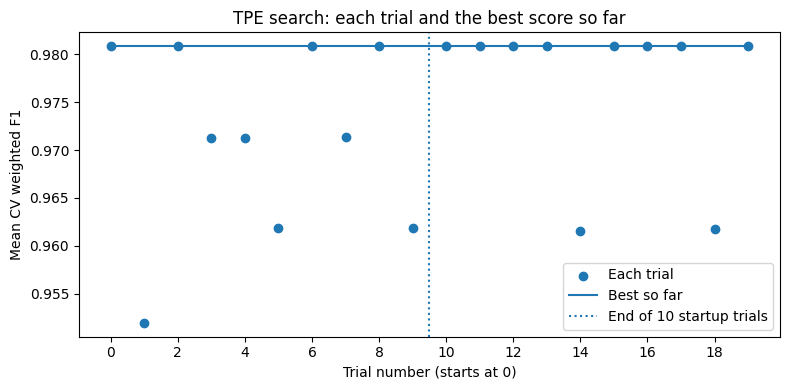

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(tpe_search_result["number"], tpe_search_result["value"], label="Each trial")
ax.step(
    tpe_search_result["number"],
    tpe_search_result["value"].cummax(),
    where="post",
    label="Best so far",
)
ax.axvline(9.5, linestyle=":", label="End of 10 startup trials")
ax.set_xlabel("Trial number (starts at 0)")
ax.set_ylabel("Mean CV weighted F1")
ax.set_title("TPE search: each trial and the best score so far")
ax.set_xticks(range(0, len(tpe_study.trials), 2))
ax.legend()
fig.tight_layout()
plt.show()

**Fit the selected KNN.** The CV models were used to score candidates. This final model is fitted on all of `X_train` with the selected parameters.

In [ ]:
tpe_model = KNeighborsClassifier(**tpe_study.best_params)
tpe_model.fit(X_train, y_train)

y_pred = tpe_model.predict(X_test)
y_pred[:10]

array([2, 0, 2, 1, 2, 0, 1, 0, 2, 2])

## 4.6. Evaluate the selected model

We use the native TPE model for the final report, as in the supplied notebook. This choice is part of the demonstration, **not a selection made after comparing test scores**. The CV score used during the search and the test score below answer different questions.

The earlier baseline test report, test prediction previews, and all-data illustration are retained from the KNN teaching flow. This is not a strictly blind test protocol. For a clean generalization experiment, keep the test data unseen until all design choices are fixed; do not use these displayed results to change the sampler, search space, or trial budget.

In [ ]:
confusion_matrix(y_test, y_pred, labels=tpe_model.classes_)

array([[15,  0,  0],
       [ 0, 13,  2],
       [ 0,  1, 14]])

In [ ]:
print(classification_report(
    y_test, y_pred,
    target_names=iris.target_names,
    digits=4,
))

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     0.9286    0.8667    0.8966        15
   virginica     0.8750    0.9333    0.9032        15

    accuracy                         0.9333        45
   macro avg     0.9345    0.9333    0.9333        45
weighted avg     0.9345    0.9333    0.9333        45

